# Step 4 — Model Optimization and Final Evaluation

Random Forest was selected because it had the best baseline test RMSE.

The model was optimized using RandomizedSearchCV with 5-fold cross-validation. The search used only the training data. The test data remained unseen until the final evaluation.


In [1]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

project_root = Path.cwd().parent
src_path = project_root / "src"
models_path = project_root / "models"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from train import load_data, split_data

In [2]:
baseline_results = pd.read_csv(
    models_path / "model_comparison.csv"
)

final_metrics = pd.read_csv(
    models_path / "final_metrics.csv"
)

optimization_results = pd.read_csv(
    models_path / "optimization_results.csv"
)

final_pipeline = joblib.load(
    models_path / "final_pipeline.joblib"
)

display(final_metrics.round(3))

,Dataset,MAE,MSE,RMSE,R2,Adjusted_R2
0,Training,5.006,40.696,6.379,0.536,0.536
1,Testing,5.093,41.921,6.475,0.524,0.522


In [3]:
final_model = final_pipeline.named_steps["model"]

best_parameters = {
    "n_estimators": final_model.n_estimators,
    "max_depth": final_model.max_depth,
    "min_samples_split": final_model.min_samples_split,
    "min_samples_leaf": final_model.min_samples_leaf,
    "max_features": final_model.max_features,
    "bootstrap": final_model.bootstrap,
}

best_parameters_dataframe = pd.DataFrame(
    best_parameters.items(),
    columns=[
        "Hyperparameter",
        "Best value",
    ]
)

display(best_parameters_dataframe)

,Hyperparameter,Best value
0,n_estimators,300
1,max_depth,8
2,min_samples_split,20
3,min_samples_leaf,4
4,max_features,1.0
5,bootstrap,True


In [4]:
best_search_result = (
    optimization_results[
        optimization_results["rank_test_score"] == 1
    ]
    .iloc[0]
)

cross_validation_rmse = (
    -best_search_result["mean_test_score"]
)

print(
    "Best cross-validation RMSE:",
    round(cross_validation_rmse, 3),
    "minutes"
)

Best cross-validation RMSE: 6.5 minutes


In [5]:
baseline_random_forest = (
    baseline_results[
        baseline_results["Model"] == "Random Forest"
    ]
    .iloc[0]
)

optimized_test = (
    final_metrics[
        final_metrics["Dataset"] == "Testing"
    ]
    .iloc[0]
)

comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Optimized Random Forest",
    ],
    "MAE": [
        baseline_random_forest["Test_MAE"],
        optimized_test["MAE"],
    ],
    "RMSE": [
        baseline_random_forest["Test_RMSE"],
        optimized_test["RMSE"],
    ],
    "R2": [
        baseline_random_forest["Test_R2"],
        optimized_test["R2"],
    ],
})

display(comparison.round(3))

,Model,MAE,RMSE,R2
0,Baseline Random Forest,5.528,7.133,0.422
1,Optimized Random Forest,5.093,6.475,0.524


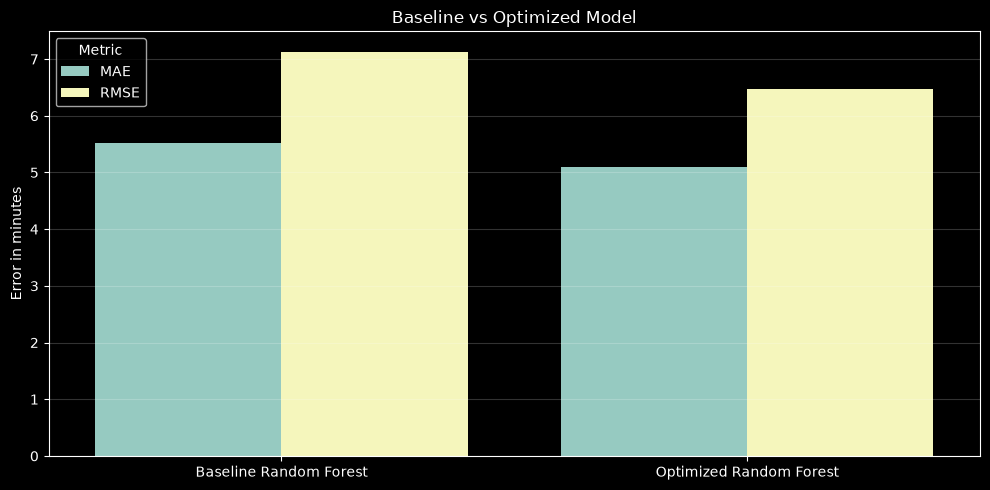

In [6]:
error_comparison = comparison.melt(
    id_vars="Model",
    value_vars=[
        "MAE",
        "RMSE",
    ],
    var_name="Metric",
    value_name="Error"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=error_comparison,
    x="Model",
    y="Error",
    hue="Metric"
)

plt.title("Baseline vs Optimized Model")
plt.xlabel("")
plt.ylabel("Error in minutes")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

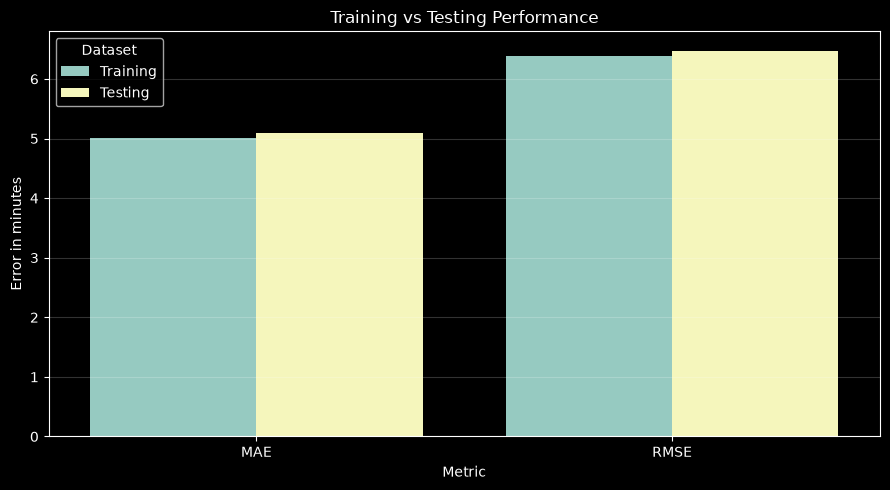

In [7]:
metrics_for_graph = final_metrics.melt(
    id_vars="Dataset",
    value_vars=[
        "MAE",
        "RMSE",
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=metrics_for_graph,
    x="Metric",
    y="Value",
    hue="Dataset"
)

plt.title("Training vs Testing Performance")
plt.ylabel("Error in minutes")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [8]:
r2_results = final_metrics[
    [
        "Dataset",
        "R2",
        "Adjusted_R2",
    ]
]

display(r2_results.round(3))

,Dataset,R2,Adjusted_R2
0,Training,0.536,0.536
1,Testing,0.524,0.522


In [9]:
dataframe = load_data()

X_train, X_test, y_train, y_test = split_data(
    dataframe
)

test_predictions = final_pipeline.predict(
    X_test
)

prediction_results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": test_predictions,
})

display(prediction_results.head())

Dataset loaded: /home/bsar/Desktop/delivery-eta/data/processed/food_delivery_featured.csv
Dataset shape: (40353, 9)
Training rows: 32282
Testing rows: 8071


,Actual,Predicted
0,17.0,20.661725
1,31.0,29.430109
2,24.0,29.997860
3,48.0,39.973991
4,28.0,18.955448


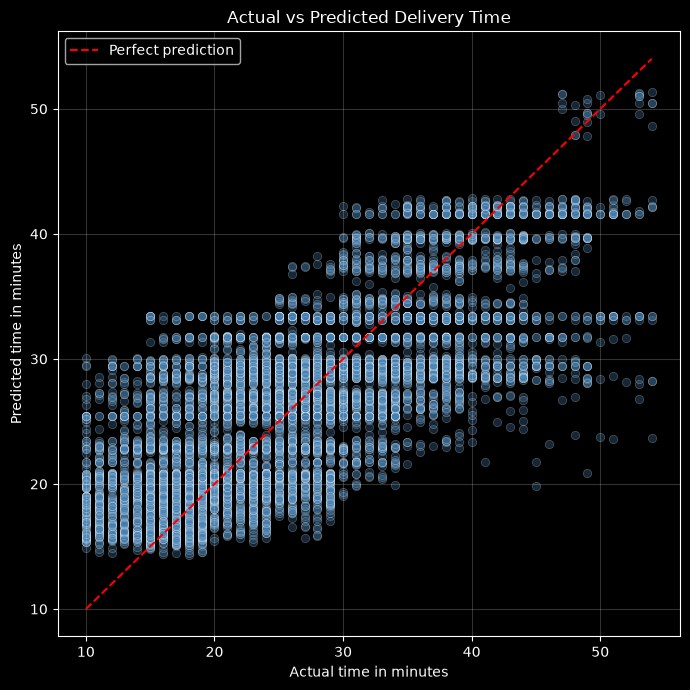

In [10]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=prediction_results,
    x="Actual",
    y="Predicted",
    alpha=0.3,
    color="steelblue"
)

minimum_value = min(
    prediction_results["Actual"].min(),
    prediction_results["Predicted"].min()
)

maximum_value = max(
    prediction_results["Actual"].max(),
    prediction_results["Predicted"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual time in minutes")
plt.ylabel("Predicted time in minutes")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [11]:
test_metrics = final_metrics[
    final_metrics["Dataset"] == "Testing"
].iloc[0]

print(
    f"The optimized model makes an average error "
    f"of {test_metrics['MAE']:.2f} minutes."
)

print(
    f"Its RMSE is "
    f"{test_metrics['RMSE']:.2f} minutes."
)

print(
    f"It explains "
    f"{test_metrics['R2'] * 100:.1f}% "
    f"of the variation in delivery time."
)

print(
    f"Its adjusted R² is "
    f"{test_metrics['Adjusted_R2']:.3f}."
)

The optimized model makes an average error of 5.09 minutes.
Its RMSE is 6.47 minutes.
It explains 52.4% of the variation in delivery time.
Its adjusted R² is 0.522.
